In [10]:
# This file is to experiment with LightGBM before committing to model.

import numpy as np
import pandas as pd
import lightgbm as lgb
from eda import make_pixel_df, train_val_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Make global variables for the feature names, expert labeled
# images, and filepath to figs directory.
COORDS = ["y", "x"]
RAD_ANGLES = ["DF", "CF", "BF", "AF", "AN"]
SYN_FTRS = ["NDAI", "SD", "CORR"]
EXP_LAB = "Expert Label"
FTRS = COORDS + SYN_FTRS + ["Radiance Angle " + ang for ang in RAD_ANGLES] \
    + [EXP_LAB]

# Start by loading in autoencoder latent vector.
lat_vec = np.load("results/part3_latent_vectors.npz")

# Extract X and y from latent vector.
X_lat = lat_vec["X"]
y_lat = lat_vec["y"]

# Convert latent vector components to pandas df and series.
X_lat = pd.DataFrame(X_lat)
y_lat = pd.Series(y_lat)

# Concatenate to make latent dataframe and rename to AE features
# and expert label
lat_df = pd.concat([X_lat, y_lat], axis=1)
lat_df.columns = ["AE" + str(idx) for idx in range(8)] + [EXP_LAB]

In [11]:

# Make pixel_df out of raw data file.
pixel_df = make_pixel_df()

# Filter the data frame just to the labeled images.
labeled_df = pixel_df[pixel_df[EXP_LAB].notna()]

# Drop the unlabeled pixels from the labeled dataframe.
given_df = labeled_df[labeled_df[EXP_LAB] != 0]

# Drop the coordinates columns.
given_df = given_df.drop(columns=COORDS)

# Recode given_df to have clear be 0 instead of -1.
given_df[EXP_LAB] = given_df[EXP_LAB].replace(-1, 0)

# Change index of given_df to match lat_df.
given_df.set_index(lat_df.index, inplace=True)

100%|██████████| 164/164 [00:06<00:00, 26.93it/s]


In [12]:
# Make latent + given df by concatenation.
combined_df = pd.concat([given_df.drop(columns=[EXP_LAB]), lat_df], 
                        axis=1, join="inner")

# Update lat_df to include image label.
lat_df = combined_df.drop(columns=FTRS[2:-1])

Average Accuracy with Given Features: 0.96108
Average Accuracy with Autoencoder Features: 0.91802
Average Accuracy with Combined Features: 0.97471


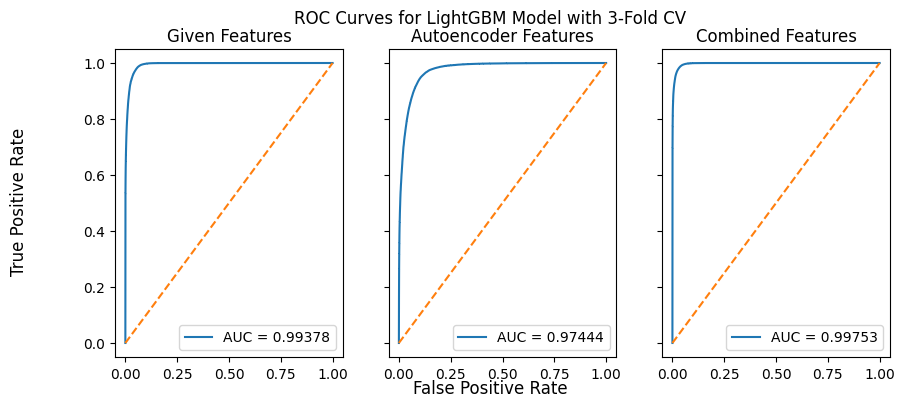

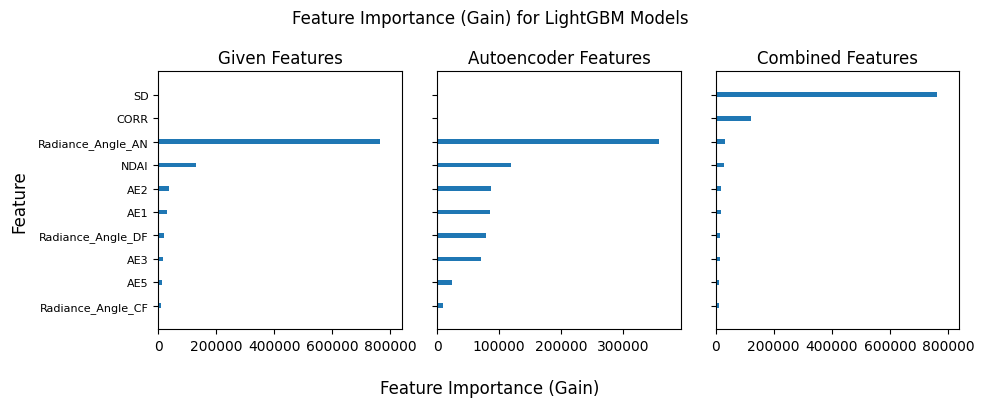

In [14]:
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# Set random state to 1 for reproducibility.
random_state = 1

# Make a 1 x 3 grid of subplots for ROC curves.
fig, axs = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

# Make a 1 x 3 grid of subplots for feature importance.
fig_imp, axs_imp = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

# Iterate through the dataframes and make LightGBM models
# for all three.
df_lst = [given_df, lat_df, combined_df]
subplot_titles = ["Given Features", "Autoencoder Features", "Combined Features"]

for df_idx in range(len(df_lst)):
    # Get train/val/test splits.
    X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(
        df_lst[df_idx],
        random_state
    )

    # Combine training and validation sets since we are about
    # to perform 3-fold cross-validation on this combined set.
    X_cv = pd.concat([X_train, X_val]).reset_index(drop=True)
    y_cv = pd.concat([y_train, y_val]).reset_index(drop=True)

    # Make 3-fold CV splits on the combined CV data.
    kf = KFold(n_splits=3, shuffle=True, random_state=random_state)

    # Initialize a list to store performance metrics across folds.
    metrics = []

    # Store out-of-fold predicted probabilities for ROC curve.
    y_scores = np.zeros(len(y_cv))
    y_true = y_cv.reset_index(drop=True)

    # Iterate through folds to perform cross-validation.
    for train_idx, test_idx in kf.split(X_cv):
        # Split the combined dataset into training and validation
        # subsets for this fold using index-based selection.
        X_fold_train, X_fold_test = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
        y_fold_train, y_fold_test = y_cv.iloc[train_idx], y_cv.iloc[test_idx]

        # Make LightGBM dataset for training.
        train_data = lgb.Dataset(X_fold_train, label=y_fold_train)

        # Train the model using default parameters.
        # (Specify objective explicitly if needed.)
        params = {
            "objective": "binary",
            "verbosity": -1
        }
        bst = lgb.train(params, train_data)

        # Make predictions on the validation fold.
        y_pred = bst.predict(X_fold_test)

        # Save predicted probabilities for ROC curve.
        y_scores[test_idx] = y_pred

        # Convert predicted probabilities into class labels.
        # For binary classification, threshold at 0.5.
        y_pred_labels = (y_pred >= 0.5).astype(int)

        # Calculate accuracy for this fold and store it.
        accuracy = accuracy_score(y_fold_test, y_pred_labels)
        metrics.append(accuracy)
    
    # Make dictionary mapping df_idx to df names.
    df_dict = {0: "Given Features",
               1: "Autoencoder Features",
               2: "Combined Features"}

    # Calculate the average accuracy across all folds.
    average_accuracy = np.mean(metrics)
    print(f"Average Accuracy with {df_dict[df_idx]}: {round(average_accuracy, 5)}")

    # Compute ROC curve and AUC.
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve on subplot, rounded to 5 decimal places.
    axs[df_idx].plot(fpr, tpr, label=f"AUC = {round(roc_auc, 5)}")
    axs[df_idx].plot([0, 1], [0, 1], linestyle="--")
    axs[df_idx].set_title(subplot_titles[df_idx])
    axs[df_idx].legend(loc="lower right")

    # Train model on full CV data to get feature importance.
    train_data_full = lgb.Dataset(X_cv, label=y_cv)
    bst_full = lgb.train(params, train_data_full)

    # Plot feature importance (gain) on subplot but get rid
    # of x-axis and y-axis labels.
    lgb.plot_importance(
        bst_full,
        importance_type="gain",
        ax=axs_imp[df_idx],
        title=subplot_titles[df_idx],
        xlabel=None,
        ylabel=None,
        max_num_features=10,
        grid=False
    )

    # Remove raw gain labels on the bars.
    for text in axs_imp[df_idx].texts:
        text.set_visible(False)

    # Clean axis labels and make feature labels smaller
    # since they were causing clutter by default.
    axs_imp[df_idx].tick_params(axis="y", labelsize=8)

# Make shared axis labels and overall title for ROC curves.
fig.supxlabel("False Positive Rate")
fig.supylabel("True Positive Rate")
fig.suptitle("ROC Curves for LightGBM Model with 3-Fold CV")
    
# Set overall title and axis labels for feature importance plots.
fig_imp.suptitle("Feature Importance (Gain) for LightGBM Models")
fig_imp.supxlabel("Feature Importance (Gain)")
fig_imp.supylabel("Feature")

# Use tight layout to avoid overlapping and show the plots.
plt.tight_layout()

# Display the plots.
plt.show()